# Flow of a Darcy fluid in an annulus

$$
\mathbb{S}_p
\begin{cases}
\Omega = \{(x, y)~:~R_{\text{inner}}^2 < x^2 + y^2 < R_{\text{outer}}^2\} \\
\partial\Omega_{\text{inner}} = \{(x, y)~:~ x^2 + y^2 = R_{\text{inner}}^2 \} \\
\partial\Omega_{\text{outer}} = \{(x, y)~:~ x^2 + y^2 = R_{\text{outer}}^2 \} \\
p_{\text{D}}\vert_{\partial\Omega_{\text{inner}}}=p_{\text{in}} \\
p_{\text{D}}\vert_{\partial\Omega_{\text{outer}}}=0 \\
\mathsf{K}(x,y)=\left(1 + \epsilon\sin\left(n\tan^{-1}(y/x)\right)\right)\mathsf{I} \\
\mu=1 \\
\end{cases}
$$

In [1]:
import numpy as np
from lucifex.fem import Function, Constant
from lucifex.mesh import annulus_mesh, mesh_boundary
from lucifex.solver import BoundaryConditions, bvp, interpolation
from lucifex.plt import plot_contours, plot_mesh, plot_colormap, plot_quiver, save_figure
from lucifex.pde.darcy import darcy_pressure, darcy_velocity_from_pressure
from lucifex.pde.streamfunction_vorticity import streamfunction_from_velocity

Rinner = 0.1
Router = 1.0
Nradial = 30
dr = (Router - Rinner) / Nradial
mesh = annulus_mesh(dr, 'triangle')(Rinner, Router)

r2 = lambda x: x[0]**2 + x[1]**2
theta = lambda x: np.arctan2(x[1], x[0])
boundary = mesh_boundary(
    mesh, 
    {
        "inner": lambda x: r2(x) - Rinner**2,
        "outer": lambda x: r2(x) - Router**2,
    },
)

mu = Constant(mesh, 1.0)
eps = 0.25
n = 8
kx = lambda x: 1 + eps * np.cos(n * theta(x))
k = Function((mesh, 'P', 1), kx)

p_in = 1.0
p_bcs = BoundaryConditions(
    ("dirichlet", boundary['inner'], p_in),
    ("dirichlet", boundary['outer'], 0.0),  
)

p = Function((mesh, 'P', 2), name='p')
p_solver = bvp(darcy_pressure, p_bcs)(p, k, mu)

u = Function((mesh, 'P', 1, 2), name='u')
u_solver = interpolation(u, darcy_velocity_from_pressure)(p, k, mu)

psi = Function((mesh, 'P', 1), name='p')
psi_solver = bvp(streamfunction_from_velocity)(psi, u)

p_solver.solve()
u_solver.solve()
psi_solver.solve()

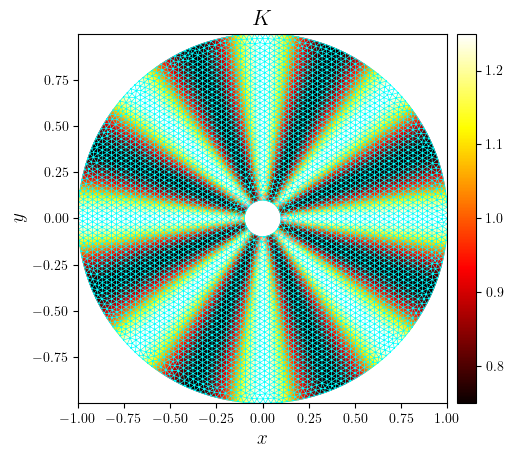

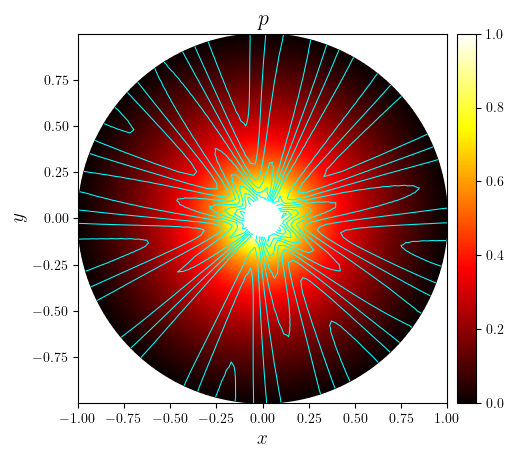

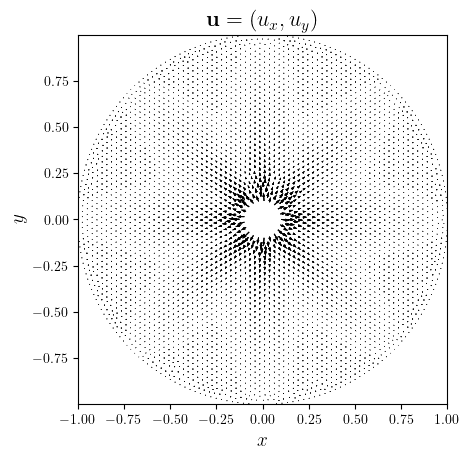

: 

In [ ]:
fig, ax = plot_colormap(k, title='$K$', x_label='$x$', y_label='$y$')
plot_mesh(fig, ax, mesh, color='cyan', linewidth=0.5)
save_figure('K(x,y)_mesh')(fig)

fig, ax = plot_colormap(p, title='$p$', x_label='$x$', y_label='$y$')
plot_contours(fig, ax, psi, colors='cyan', levels=20)
save_figure('p(x,y)_streamlines', thumbnail=True)(fig)

fig, ax = plot_quiver(u, title="$\mathbf{u}=(u_x, u_y)$")
save_figure('u(x,y)_quiver')(fig)